# DC/IRP 퇴직연금 포트폴리오 최적화 + XAI — 통합 분석 노트북

**목적**: Black-Litterman 기반 하방위험 최소화 포트폴리오 + Risk Score 개인화 + 사용자 설명가능 AI(XAI)

| 항목 | 내용 |
|------|------|
| 하방공분산 | Estrada(2007) $\Sigma_{down} = D^T D / T$, $D = \min(r - MAR, 0)$ |
| BL 내재수익률 | $\Pi = \lambda \cdot \Sigma_{down} \cdot w_{mkt}$, $\lambda = 3.0$ |
| 최적화 | Sortino 비율 최대화 (SLSQP), US≤50% / KR≤50% / EM≤15% |
| 개인화 | Risk Score(1~10) → CAL w_risky 선형 보간 → 최종 배분 |
| 기간 | 백테스트 2016~2025 (38분기), 5년 롤링 윈도우 |

---
**실행 순서**:
1. `0. 설정` 셀 실행 (필수)
2. `1. 파이프라인 실행` 셀 — 처음 실행 시에만 필요 (약 10~30분)
3. `2. 결과 로드` 이후 — 순서대로 실행
4. `7. XAI 사용자 대면` → `★ 투자자 입력값` 셀만 수정 후 전체 실행

## 0. 설정 & 공통 유틸리티

In [2]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
from pathlib import Path
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

# ── 경로 ──
ROOT    = Path('..').resolve()
DATA_DIR = ROOT / 'data'
S4_DIR  = ROOT / 'results' / 'step4'
S5_DIR  = ROOT / 'results' / 'step5'
S6_DIR  = ROOT / 'results' / 'step6'
S7_DIR  = ROOT / 'results' / 'step7'
CUR_DIR = ROOT / 'results' / 'current'

sys.path.insert(0, str(ROOT / 'src'))

# ── 시각화 설정 ──
plt.rcParams['font.family']        = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']         = 110
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

DISCLAIMER = '※ 투자 참고 정보입니다. 미래 수익을 보장하지 않으며, 투자 결정은 투자자 본인이 합니다.'

SLOTS = [
    '국내주식_코스피', '국내주식_코스닥',
    '미국주식_SP500',  '미국주식_나스닥',
    '신흥국_인도',     '신흥국_중국',
    '국내채권_국고채단중기', '국내채권_국고채장기',
    '국내채권_회사채', '국내채권_종합',
    '해외채권_미국국채',
    '원자재_금',
    '무위험(현금성)',
]
SLOTS_GROUPED = {
    '국내주식': ['국내주식_코스피', '국내주식_코스닥'],
    '미국주식': ['미국주식_SP500', '미국주식_나스닥'],
    '신흥국':   ['신흥국_인도', '신흥국_중국'],
    '국내채권': ['국내채권_국고채단중기','국내채권_국고채장기','국내채권_회사채','국내채권_종합'],
    '해외채권': ['해외채권_미국국채'],
    '원자재':   ['원자재_금'],
    '무위험':   ['무위험(현금성)'],
}
GROUP_COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948','#b07aa1']
DEMO_SCORES  = [2.0, 4.0, 6.0, 7.2, 9.0]
SCORE_LABELS = {2.0:'초보수형', 4.0:'보수형', 6.0:'중립형', 7.2:'성장형', 9.0:'공격형'}
SCORE_COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

print(f"ROOT : {ROOT}")
print(f"Python : {sys.version[:6]}")

ROOT : G:\내 드라이브\03_DArt-B\22_학술제\퇴직연금 _XAI
Python : 3.13.1


In [3]:
# ── 데이터 / 결과 파일 존재 여부 확인 ──
check = {
    'index_returns':              DATA_DIR / 'index_returns.parquet',
    'mar_series':                 DATA_DIR / 'mar_series.parquet',
    'step5/portfolio_weights':    S5_DIR   / 'portfolio_weights_constrained.parquet',
    'step5/portfolio_performance':S5_DIR   / 'portfolio_performance_constrained.parquet',
    'step5/sigma_down_history':   S5_DIR   / 'sigma_down_history.parquet',
    'step5/pi_history':           S5_DIR   / 'pi_history.parquet',
    'step5/binding_history':      S5_DIR   / 'binding_history.parquet',
    'step5/weights_mvp':          S5_DIR   / 'portfolio_weights_mvp.parquet',
    'step5/performance_mvp':      S5_DIR   / 'portfolio_performance_mvp.parquet',
    'step6/cal_demo':             S6_DIR   / 'cal_demo_allocations.parquet',
    'step7/lambda_implied':       S7_DIR   / 'lambda_implied.parquet',
    'current/sortino':            CUR_DIR  / 'current_weights_sortino.csv',
    'current/mvp':                CUR_DIR  / 'current_weights_mvp.csv',
}
ok, miss = [], []
for name, path in check.items():
    (ok if path.exists() else miss).append(name)

print(f"[OK  {len(ok):>2}]  " + ', '.join(ok[:5]) + ('...' if len(ok) > 5 else ''))
if miss:
    print(f"[MISS {len(miss):>2}]  " + ', '.join(miss))
    print("\n→ 아래 '1. 파이프라인 실행' 셀을 먼저 실행하세요.")
else:
    print("→ 모든 파일 존재. '2. 결과 로드'로 바로 이동 가능.")

[OK  13]  index_returns, mar_series, step5/portfolio_weights, step5/portfolio_performance, step5/sigma_down_history...
→ 모든 파일 존재. '2. 결과 로드'로 바로 이동 가능.


## 1. 파이프라인 실행 (최초 1회만)

> 이미 `results/` 결과 파일이 있으면 이 섹션을 건너뛰세요.  
> 처음 실행 시: Step 3 → Step 5 → Step 6 → Step 7 → Step 6b 순서로 실행합니다.

| 스크립트 | 소요 시간 (예상) | 출력 |
|---------|----------------|------|
| step3_collect_data.py | 2~5분 | index_returns.parquet, mar_series.parquet |
| step5_constrained.py  | 10~20분 | results/step5/*.parquet |
| step6_cal.py          | 30초 | results/step6/*.csv |
| step7_lambda_implied.py | 1분 | results/step7/*.parquet |
| step6b_current_allocation.py | 1분 | results/current/*.csv |

In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 실행할 스텝만 True로 변경하세요
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RUN_STEP3 = False   # 기초자산 지수 수집 (yfinance + ECOS API)
RUN_STEP5 = False   # 제약 포트폴리오 + MVP 백테스트 (가장 오래 걸림)
RUN_STEP6 = False   # CAL + Risk Score 매핑
RUN_STEP7 = False   # λ_implied 역산
RUN_STEP6B= False   # 현재 시점 배분 (라이브 서비스)

import subprocess, sys as _sys

def run_script(name):
    path = ROOT / 'src' / name
    print(f"▶ {name} 실행 중...")
    result = subprocess.run(
        [_sys.executable, str(path)],
        capture_output=True, text=True, cwd=str(ROOT)
    )
    if result.returncode != 0:
        print(f"  ✗ 오류:\n{result.stderr[-2000:]}")
    else:
        last = [l for l in result.stdout.split('\n') if l.strip()][-3:]
        print('\n'.join(f"  {l}" for l in last))
        print(f"  ✓ 완료")

if RUN_STEP3:  run_script('step3_collect_data.py')
if RUN_STEP5:  run_script('step5_constrained.py')
if RUN_STEP6:  run_script('step6_cal.py')
if RUN_STEP7:  run_script('step7_lambda_implied.py')
if RUN_STEP6B: run_script('step6b_current_allocation.py')

if not any([RUN_STEP3, RUN_STEP5, RUN_STEP6, RUN_STEP7, RUN_STEP6B]):
    print("모든 플래그 False → 파이프라인 실행 건너뜀")

모든 플래그 False → 파이프라인 실행 건너뜀


## 2. 결과 로드

In [5]:
from step6_cal import score_to_w_risky, compute_cal_allocation

# ── Step 5 ──
w_con    = pd.read_parquet(S5_DIR / 'portfolio_weights_constrained.parquet')
perf_con = pd.read_parquet(S5_DIR / 'portfolio_performance_constrained.parquet')
w_mvp    = pd.read_parquet(S5_DIR / 'portfolio_weights_mvp.parquet')
perf_mvp = pd.read_parquet(S5_DIR / 'portfolio_performance_mvp.parquet')
sigma_h  = pd.read_parquet(S5_DIR / 'sigma_down_history.parquet')
pi_h     = pd.read_parquet(S5_DIR / 'pi_history.parquet')
bind_h   = pd.read_parquet(S5_DIR / 'binding_history.parquet')

# ── Step 6 & 7 ──
cal_df   = pd.read_parquet(S6_DIR / 'cal_demo_allocations.parquet').reset_index()
lam_df   = pd.read_parquet(S7_DIR / 'lambda_implied.parquet').reset_index()

# ── 현재 시점 비중 ──
try:
    cur_w   = pd.read_csv(CUR_DIR / 'current_weights_sortino.csv', index_col=0)['weight']
    cur_mvp = pd.read_csv(CUR_DIR / 'current_weights_mvp.csv',    index_col=0)['weight']
except FileNotFoundError:
    cur_w   = w_con.iloc[-1]
    cur_mvp = w_mvp.iloc[-1]
    print("  current/ 없음 → 마지막 분기 비중 사용")

# ── 누적 수익률 지수 ──
cum_con = (1 + perf_con['cum_ret_pct'] / 100).cumprod()
cum_mvp = (1 + perf_mvp['cum_ret_pct'] / 100).cumprod()

def _mdd(s):
    return float(((s - s.cummax()) / s.cummax()).min())

MDD_CON     = _mdd(cum_con)
MDD_MVP     = _mdd(cum_mvp)
ANN_RET_CON = float(cum_con.iloc[-1] ** (4 / len(cum_con)) - 1)
ANN_RET_MVP = float(cum_mvp.iloc[-1] ** (4 / len(cum_mvp)) - 1)

print(f"Step 5  분기: {len(w_con)}개  ({w_con.index.min().date()} ~ {w_con.index.max().date()})")
print(f"Sortino-max: 누적 {(cum_con.iloc[-1]-1)*100:.1f}%  연환산 {ANN_RET_CON*100:.2f}%  MDD {MDD_CON*100:.2f}%")
print(f"MVP        : 누적 {(cum_mvp.iloc[-1]-1)*100:.1f}%  연환산 {ANN_RET_MVP*100:.2f}%  MDD {MDD_MVP*100:.2f}%")
print(f"λ_implied  : {len(lam_df)}행  (분기 × 5개 Risk Score)")

▶ Step 5 결과 로드...
  분기 수: 38개 (2016-01-29 ~ 2025-01-16)

【 Risk Score → w_risky 매핑 (일부) 】
 risk_score  w_risky  w_riskfree  위험군
        1.0      0.0         1.0 초보수형
        3.0      0.2         0.8  보수형
        5.0      0.4         0.6  중립형
        7.0      0.6         0.4  성장형
        9.0      0.7         0.3  공격형
       10.0      0.7         0.3  공격형

【 최근 리밸런싱 (2025-01-16) 대표 Risk Score별 최종 배분 (%) 】
슬롯                           RS 2.0 RS 4.0 RS 6.0 RS 7.2 RS 9.0
------------------------------------------------------------------------------
국내주식_코스피                          0.1%      0.3%      0.5%      0.6%      0.7%
국내주식_코스닥                          2.7%      8.1%     13.5%     16.5%     18.9%
미국주식_SP500                        1.0%      3.0%      5.0%      6.1%      7.0%
미국주식_나스닥                          4.0%     12.0%     20.0%     24.4%     28.0%
신흥국_인도                            0.1%      0.3%      0.5%      0.6%      0.7%
신흥국_중국                            1.4%      4.2%      7

## 3. 이론적 배경

### 3-1. Estrada(2007) 하방공분산

$$\Sigma^{down}_{ij} = \frac{1}{T} \sum_{t=1}^{T} \min(r_{i,t} - MAR_t, 0) \cdot \min(r_{j,t} - MAR_t, 0)$$

- **MAR**: ECOS 정기예금 6개월 미만 금리 (시변, 연율 → 일별)
- **특성**: 상방 수익률을 제거하여 하방 움직임의 공동 패턴만 포착

### 3-2. Black-Litterman 내재수익률

$$\Pi = \lambda \cdot \Sigma^{down} \cdot w_{mkt}, \quad \lambda = 3.0$$

- $w_{mkt}$: 전년도 연도말 최우수 ETF의 AUM 기반 시장 비중
- $\lambda = 3.0$: 퇴직연금 보수성 반영 (일반 시장 $\lambda \approx 2.5$ 대비 상향)

### 3-3. Sortino 비율 최대화 (SLSQP)

$$\max_{w} \frac{w^T \Pi \cdot T_{rebal} - MAR_q}{\sqrt{w^T \Sigma^{down} w \cdot T_{rebal}}}$$

$$\text{s.t.} \quad \sum w_i = 1, \quad w_i \in [1\%, 40\%], \quad w_{US} \leq 50\%, \quad w_{KR} \leq 50\%, \quad w_{EM} \leq 15\%$$

### 3-4. Capital Allocation Line (CAL)

$$w^{final} = w_{risky} \times w^{Sortino} + (1 - w_{risky}) \times w^{RF}$$

$$w_{risky} = \text{LinearInterp}(RS; \, [1,3,5,7,9] \to [0\%, 20\%, 40\%, 60\%, 70\%])$$

- DC/IRP 위험자산 법적 상한: **70%**

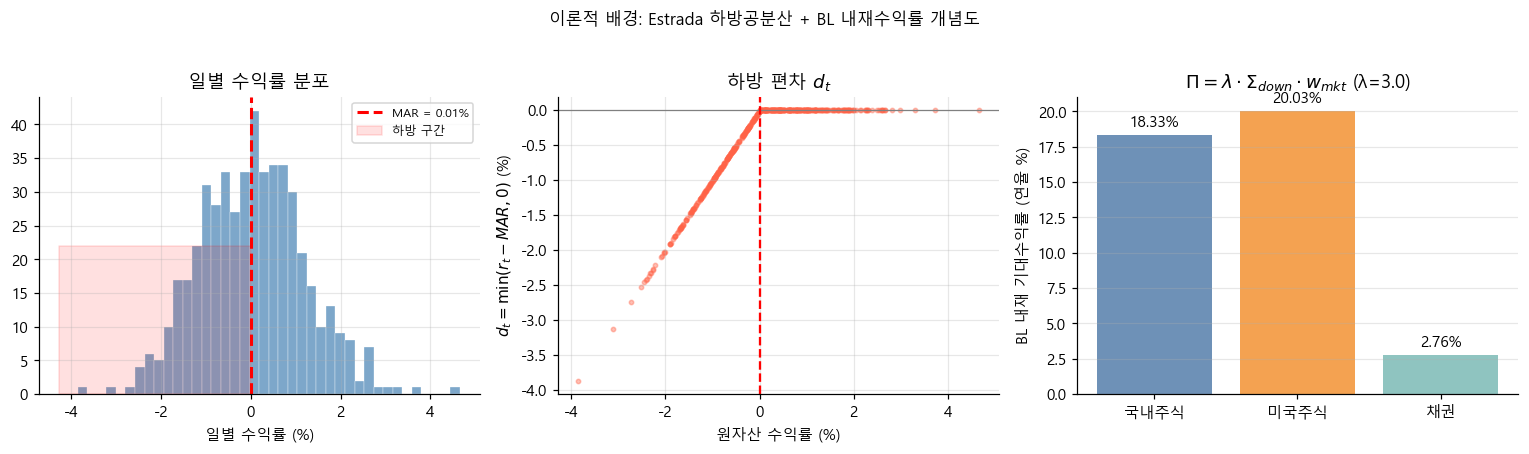

In [6]:
# ── BL 내재수익률 개념 시각화: Σ_down vs 일반 Σ 비교 ──
np.random.seed(42)
n = 500
mar = 0.0001
r   = np.random.normal(0.0003, 0.012, n)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 수익률 분포
ax = axes[0]
ax.hist(r * 100, bins=40, color='steelblue', alpha=0.7, edgecolor='white', lw=0.3)
ax.axvline(mar * 100, color='red', lw=2, ls='--', label=f'MAR = {mar*100:.2f}%')
ax.fill_betweenx([0, 22], ax.get_xlim()[0], mar * 100, alpha=0.12, color='red', label='하방 구간')
ax.set_xlabel('일별 수익률 (%)')
ax.set_title('일별 수익률 분포')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 일반 공분산 vs 하방공분산
ax2 = axes[1]
d   = np.minimum(r - mar, 0)
ax2.scatter(r * 100, d * 100, s=8, alpha=0.4, color='tomato')
ax2.axhline(0, color='gray', lw=0.8)
ax2.axvline(mar * 100, color='red', ls='--', lw=1.5)
ax2.set_xlabel('원자산 수익률 (%)')
ax2.set_ylabel('$d_t = \\min(r_t - MAR, 0)$ (%)')
ax2.set_title('하방 편차 $d_t$')
ax2.grid(alpha=0.3)

# π 개념도 (3슬롯 예시)
ax3 = axes[2]
lam = 3.0
w_mkt_ex = np.array([0.4, 0.35, 0.25])
names_ex  = ['국내주식', '미국주식', '채권']
sigma_ex  = np.array([[0.0004, 0.0002, 0.00005],
                       [0.0002, 0.0005, 0.00004],
                       [0.00005, 0.00004, 0.00001]])
pi_ex = lam * sigma_ex @ w_mkt_ex * 252 * 100  # 연율 %
bars = ax3.bar(names_ex, pi_ex, color=['#4e79a7','#f28e2b','#76b7b2'], alpha=0.82)
ax3.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax3.set_ylabel('BL 내재 기대수익률 (연율 %)')
ax3.set_title(f'$\\Pi = \\lambda \\cdot \\Sigma_{{down}} \\cdot w_{{mkt}}$ (λ={lam})')
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('이론적 배경: Estrada 하방공분산 + BL 내재수익률 개념도', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 4. 백테스트 성과 분석 (Step 5)

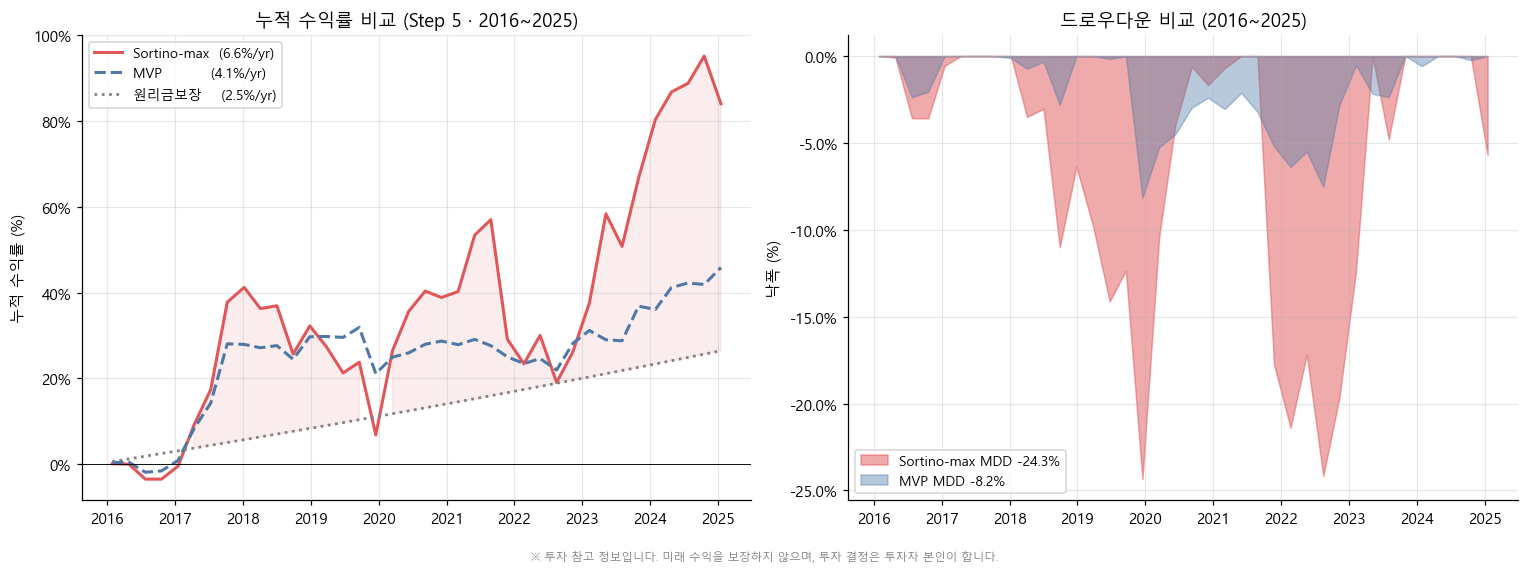

,Sortino-max,MVP
연환산 수익률,6.63%,4.05%
누적 수익률,84.0%,45.8%
MDD,-24.35%,-8.15%
평균 소르티노,0.599,0.464
소르티노>0 비율,60.5%,50.0%


In [7]:
# ── 누적 수익률 비교: Sortino-max vs MVP vs 원리금보장 ──
BENCH_ANNUAL = 0.025
bench_q = (1 + BENCH_ANNUAL) ** (1/4) - 1
bench_cum = pd.Series(
    (1 + bench_q) ** np.arange(1, len(cum_con) + 1),
    index=cum_con.index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 누적 수익률
ax = axes[0]
ax.plot(cum_con.index, (cum_con - 1) * 100, color='#e15759', lw=2,
        label=f'Sortino-max  ({ANN_RET_CON*100:.1f}%/yr)')
ax.plot(cum_mvp.index, (cum_mvp - 1) * 100, '--', color='#4e79a7', lw=2,
        label=f'MVP          ({ANN_RET_MVP*100:.1f}%/yr)')
ax.plot(bench_cum.index, (bench_cum - 1) * 100, ':', color='gray', lw=1.8,
        label=f'원리금보장    ({BENCH_ANNUAL*100:.1f}%/yr)')
ax.axhline(0, color='black', lw=0.6)
ax.fill_between(cum_con.index, (cum_con - 1) * 100, (bench_cum - 1) * 100,
                where=cum_con.values > bench_cum.values, alpha=0.1, color='#e15759')
ax.set_ylabel('누적 수익률 (%)')
ax.set_title('누적 수익률 비교 (Step 5 · 2016~2025)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# MDD 비교
ax2 = axes[1]
draw_d_con = ((cum_con - cum_con.cummax()) / cum_con.cummax()) * 100
draw_d_mvp = ((cum_mvp - cum_mvp.cummax()) / cum_mvp.cummax()) * 100
ax2.fill_between(draw_d_con.index, draw_d_con.values, 0, alpha=0.5, color='#e15759',
                 label=f'Sortino-max MDD {MDD_CON*100:.1f}%')
ax2.fill_between(draw_d_mvp.index, draw_d_mvp.values, 0, alpha=0.4, color='#4e79a7',
                 label=f'MVP MDD {MDD_MVP*100:.1f}%')
ax2.set_ylabel('낙폭 (%)')
ax2.set_title('드로우다운 비교 (2016~2025)')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

fig.text(0.5, -0.03, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout()
plt.show()

# 요약 테이블
summary = pd.DataFrame({
    'Sortino-max': {
        '연환산 수익률': f"{ANN_RET_CON*100:.2f}%",
        '누적 수익률':   f"{(cum_con.iloc[-1]-1)*100:.1f}%",
        'MDD':          f"{MDD_CON*100:.2f}%",
        '평균 소르티노': f"{perf_con['sortino'].mean():.3f}",
        '소르티노>0 비율': f"{(perf_con['sortino']>0).mean()*100:.1f}%",
    },
    'MVP': {
        '연환산 수익률': f"{ANN_RET_MVP*100:.2f}%",
        '누적 수익률':   f"{(cum_mvp.iloc[-1]-1)*100:.1f}%",
        'MDD':          f"{MDD_MVP*100:.2f}%",
        '평균 소르티노': f"{perf_mvp['sortino'].mean():.3f}",
        '소르티노>0 비율': f"{(perf_mvp['sortino']>0).mean()*100:.1f}%",
    }
})
display(summary)

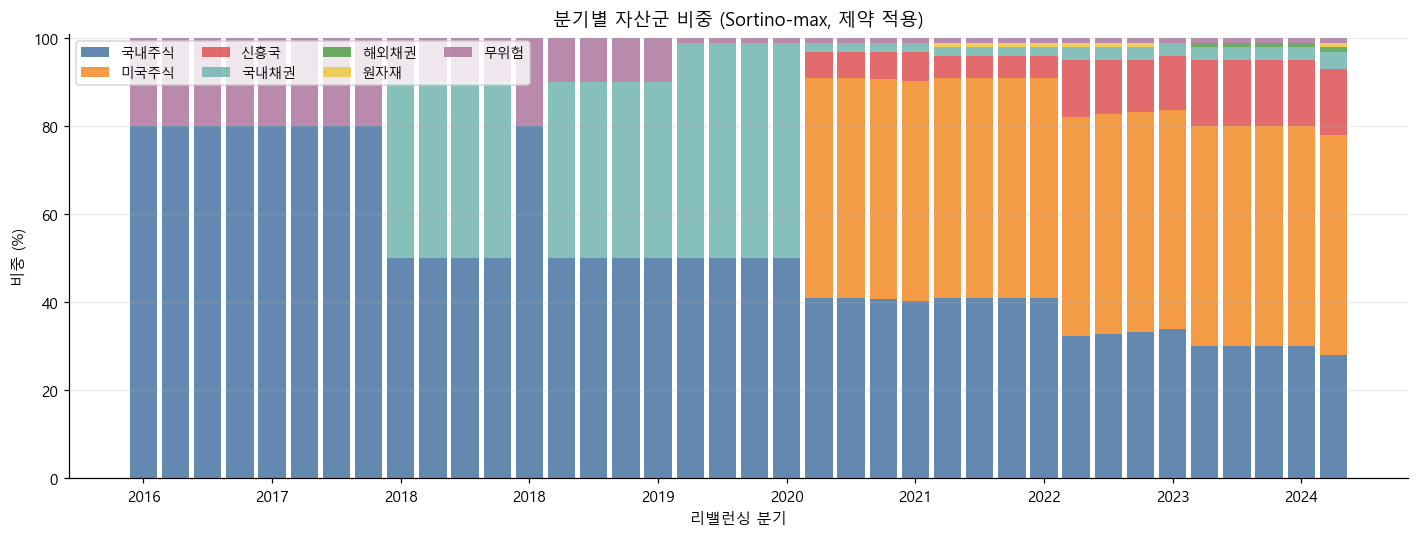

In [8]:
# ── 분기별 자산군 비중 스택 차트 (Sortino-max) ──
w_grp = pd.DataFrame(index=w_con.index)
for g, slots in SLOTS_GROUPED.items():
    w_grp[g] = w_con[[s for s in slots if s in w_con.columns]].sum(axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(w_grp))
for (g, vals), color in zip(w_grp.items(), GROUP_COLORS):
    ax.bar(range(len(w_grp)), vals.values * 100, bottom=bottom,
           color=color, alpha=0.88, label=g, width=0.85)
    bottom += vals.values * 100

ticks  = range(0, len(w_grp), 4)
labels = [w_grp.index[i].strftime('%Y') for i in ticks]
ax.set_xticks(list(ticks))
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel('비중 (%)')
ax.set_title('분기별 자산군 비중 (Sortino-max, 제약 적용)')
ax.legend(loc='upper left', ncol=4, fontsize=9)
ax.set_ylim(0, 101); ax.grid(axis='y', alpha=0.25)
ax.set_xlabel('리밸런싱 분기')
plt.tight_layout()
plt.show()

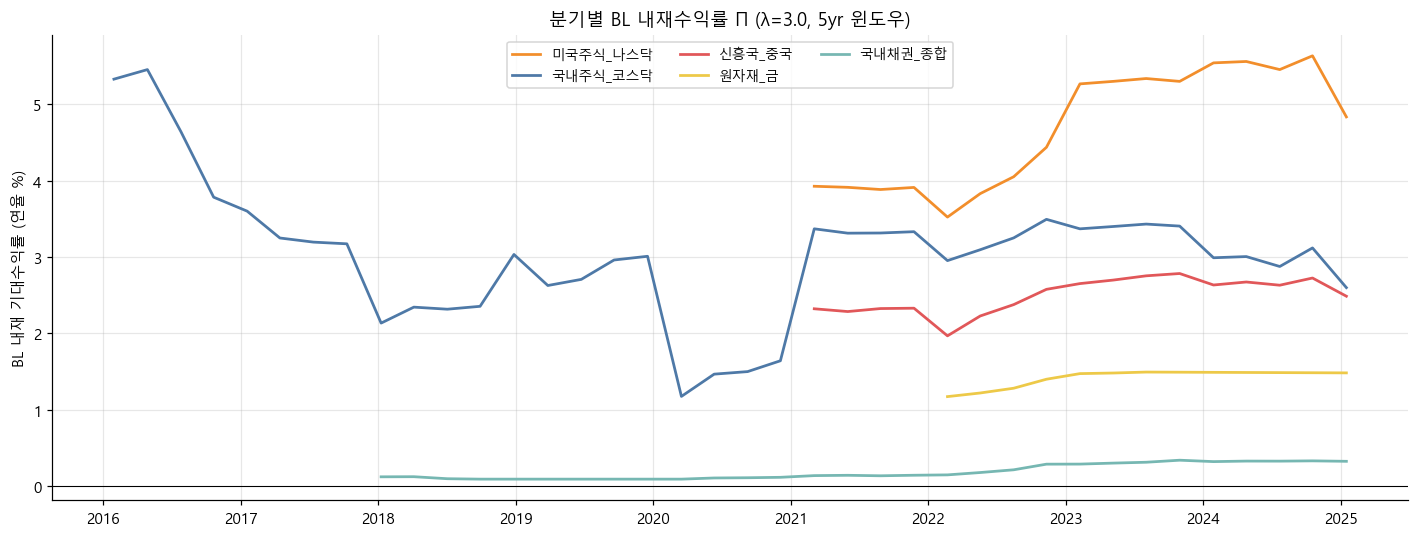

In [9]:
# ── BL 내재수익률(Π) 시계열: 슬롯별 연환산 추이 ──
PI_ANNUAL = pi_h * 252 * 100  # 일별 → 연율 %

PLOT_SLOTS = [
    ('미국주식_나스닥', '#f28e2b'),
    ('국내주식_코스닥', '#4e79a7'),
    ('신흥국_중국',     '#e15759'),
    ('원자재_금',       '#edc948'),
    ('국내채권_종합',   '#76b7b2'),
]

fig, ax = plt.subplots(figsize=(13, 5))
for slot, color in PLOT_SLOTS:
    if slot in PI_ANNUAL.columns:
        s = PI_ANNUAL[slot].dropna()
        ax.plot(s.index, s.values, lw=1.8, color=color, label=slot)

ax.axhline(0, color='black', lw=0.7)
ax.set_ylabel('BL 내재 기대수익률 (연율 %)')
ax.set_title(f'분기별 BL 내재수익률 Π (λ=3.0, 5yr 윈도우)')
ax.legend(fontsize=9, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

  미국주식: 17분기 바인딩 (44.7%)
  국내주식: 12분기 바인딩 (31.6%)
  신흥국: 5분기 바인딩 (13.2%)


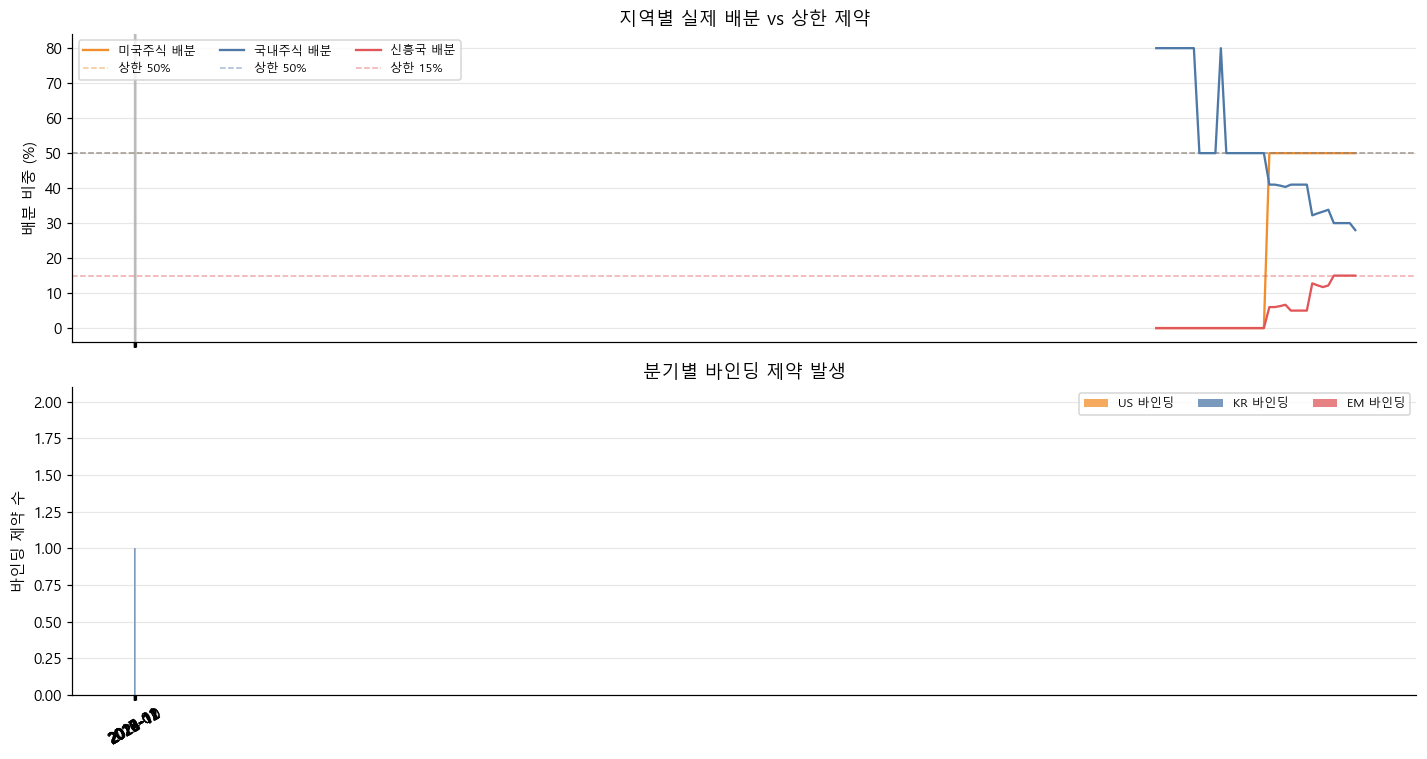

In [10]:
# ── 지역 제약 바인딩 이력 ──
bind_cols = [c for c in bind_h.columns if 'binding' in c or 'alloc' in c]
binding_pct = bind_h.copy()
for c in ['us_alloc', 'kr_alloc', 'em_alloc']:
    if c in binding_pct.columns:
        binding_pct[c] = binding_pct[c] * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# 실제 배분량
ax = axes[0]
caps = {'us_alloc': ('미국주식', 50, '#f28e2b'),
        'kr_alloc': ('국내주식', 50, '#4e79a7'),
        'em_alloc': ('신흥국',   15, '#e15759')}
for col, (label, cap, color) in caps.items():
    if col in binding_pct.columns:
        ax.plot(binding_pct.index, binding_pct[col].values,
                lw=1.5, color=color, label=f'{label} 배분')
        ax.axhline(cap, ls='--', lw=1, color=color, alpha=0.5, label=f'상한 {cap}%')
ax.set_ylabel('배분 비중 (%)')
ax.set_title('지역별 실제 배분 vs 상한 제약')
ax.legend(fontsize=8, ncol=3); ax.grid(alpha=0.3)

# 바인딩 발생 빈도
ax2 = axes[1]
bind_flags = bind_h[[c for c in bind_h.columns if 'binding' in c]].astype(int)
bottom2 = np.zeros(len(bind_flags))
bcolors = ['#f28e2b', '#4e79a7', '#e15759']
for col, color in zip(bind_flags.columns, bcolors):
    label = col.replace('_binding', '').upper() + ' 바인딩'
    ax2.bar(range(len(bind_flags)), bind_flags[col].values,
            bottom=bottom2, color=color, alpha=0.75, label=label, width=0.85)
    bottom2 += bind_flags[col].values

tick_step = max(1, len(bind_flags) // 8)
ax2.set_xticks(range(0, len(bind_flags), tick_step))
ax2.set_xticklabels([bind_flags.index[i].strftime('%Y-%m') for i in range(0, len(bind_flags), tick_step)], rotation=30)
ax2.set_ylabel('바인딩 제약 수')
ax2.set_title('분기별 바인딩 제약 발생')
ax2.legend(fontsize=8, ncol=3); ax2.grid(axis='y', alpha=0.3)

total_bind = bind_flags.sum()
n_q = len(bind_flags)
for col, (label, *_) in caps.items():
    col_b = col.replace('alloc', 'binding')
    if col_b in bind_flags.columns:
        print(f"  {label}: {total_bind[col_b]}분기 바인딩 ({total_bind[col_b]/n_q*100:.1f}%)")

plt.tight_layout()
plt.show()

## 5. CAL + Risk Score 분석 (Step 6)

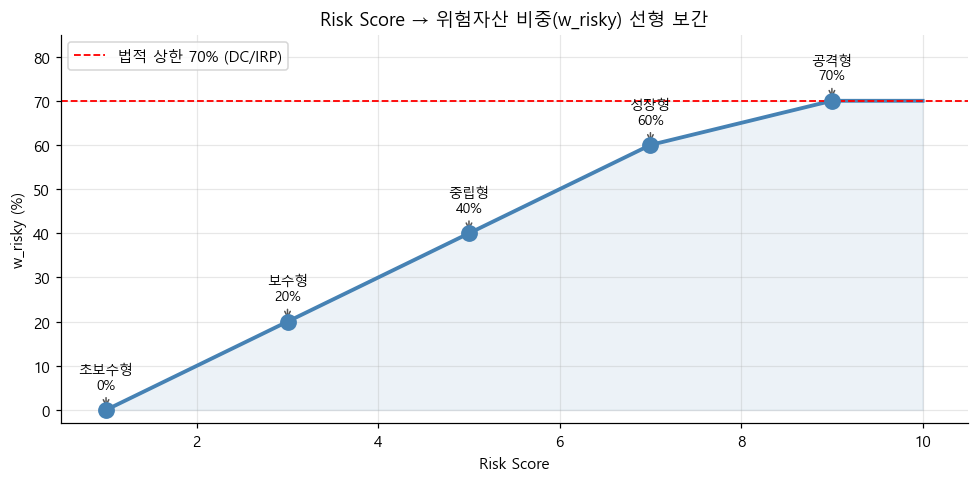

In [11]:
# ── Risk Score → w_risky 매핑 시각화 ──
scores_full = np.linspace(1, 10, 200)
w_full      = [score_to_w_risky(s) * 100 for s in scores_full]

anchors   = [1, 3, 5, 7, 9]
w_anchors = [0, 20, 40, 60, 70]
labels_a  = ['초보수형', '보수형', '중립형', '성장형', '공격형']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(scores_full, w_full, color='steelblue', lw=2.5)
ax.scatter(anchors, w_anchors, s=100, color='steelblue', zorder=5)
ax.axhline(70, ls='--', color='red', lw=1.2, label='법적 상한 70% (DC/IRP)')
for a, w, lab in zip(anchors, w_anchors, labels_a):
    ax.annotate(f"{lab}\n{w}%",
                xy=(a, w), xytext=(0, 14), textcoords='offset points',
                ha='center', fontsize=9,
                arrowprops=dict(arrowstyle='->', lw=1, color='#555'))
ax.fill_between(scores_full, w_full, alpha=0.1, color='steelblue')
ax.set_xlabel('Risk Score')
ax.set_ylabel('w_risky (%)')
ax.set_title('Risk Score → 위험자산 비중(w_risky) 선형 보간')
ax.set_xlim(0.5, 10.5); ax.set_ylim(-3, 85)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

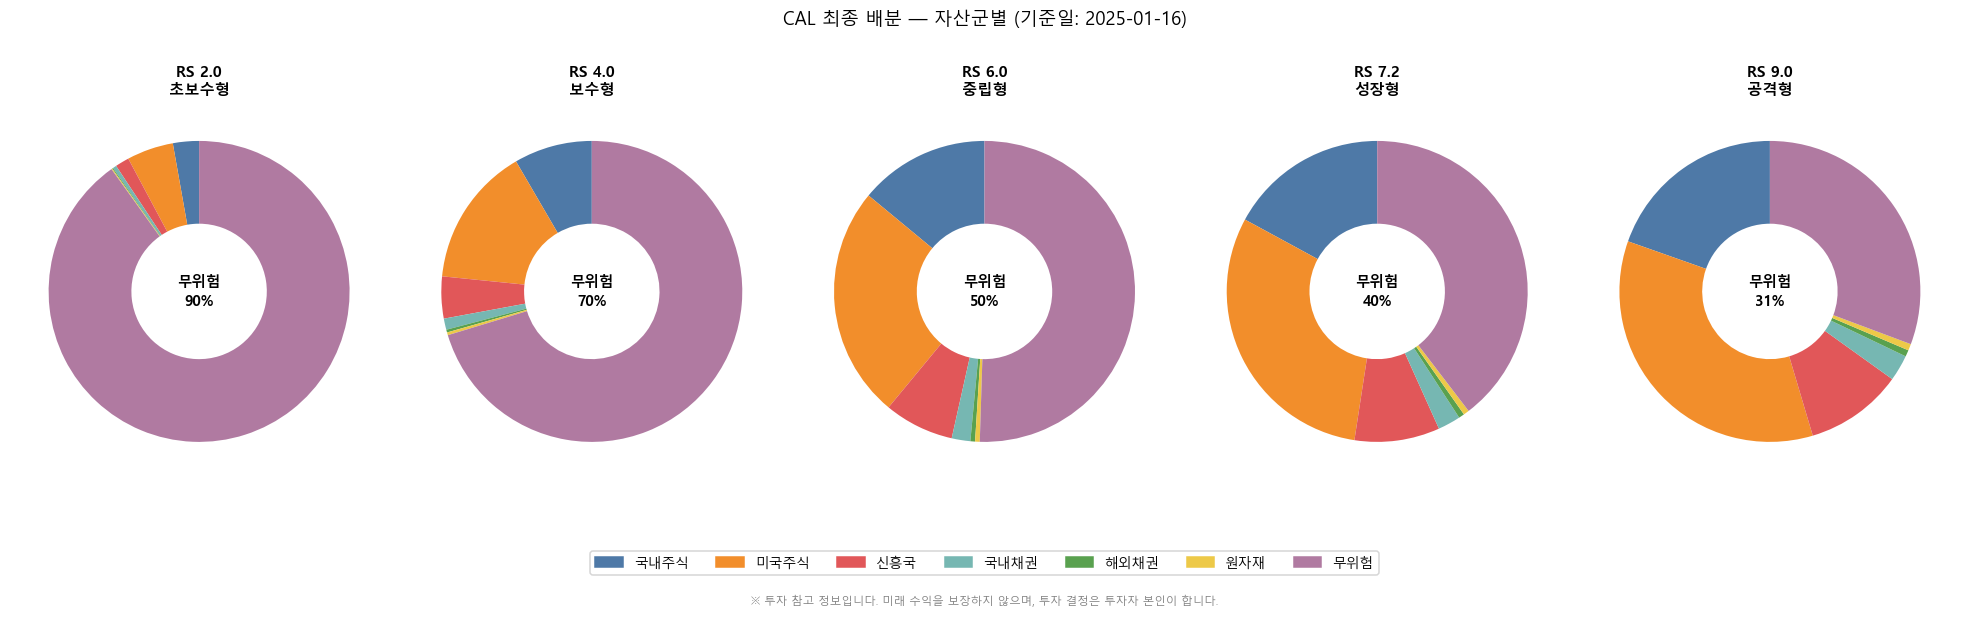


▶ 기준 Sortino-max 상위 배분 (최근 분기)
  미국주식_나스닥                         40.0%
  국내주식_코스닥                         27.0%
  신흥국_중국                           14.0%
  미국주식_SP500                       10.0%
  국내주식_코스피                          1.0%
  신흥국_인도                            1.0%
  국내채권_국고채단중기                       1.0%
  국내채권_국고채장기                        1.0%
  국내채권_회사채                          1.0%
  국내채권_종합                           1.0%
  해외채권_미국국채                         1.0%
  원자재_금                             1.0%
  무위험(현금성)                          1.0%


In [12]:
# ── 최근 분기 CAL 배분: Risk Score별 도넛 차트 ──
last_date = cal_df['date'].max()

fig, axes = plt.subplots(1, len(DEMO_SCORES), figsize=(18, 5))
for ax, rs in zip(axes, DEMO_SCORES):
    row = cal_df[(cal_df['risk_score'] == rs) & (cal_df['date'] == last_date)].iloc[0]
    groups = {}
    for g, slots in SLOTS_GROUPED.items():
        groups[g] = sum(float(row.get(s, 0)) for s in slots)
    vals   = [v for v in groups.values() if v > 0.0005]
    glabels= [g for g, v in groups.items() if v > 0.0005]
    colors = [GROUP_COLORS[list(SLOTS_GROUPED).index(g)] for g in glabels]
    wedges, _ = ax.pie(vals, colors=colors, startangle=90,
                       wedgeprops=dict(width=0.55))
    rf = float(row.get('무위험(현금성)', 0))
    ax.text(0, 0, f"무위험\n{rf*100:.0f}%",
            ha='center', va='center', fontsize=9.5, fontweight='bold')
    ax.set_title(f"RS {rs}\n{SCORE_LABELS[rs]}", fontsize=10, fontweight='bold')

handles = [mpatches.Patch(color=GROUP_COLORS[i], label=g)
           for i, g in enumerate(SLOTS_GROUPED)]
fig.legend(handles=handles, loc='lower center', ncol=7, fontsize=9,
           bbox_to_anchor=(0.5, -0.06))
fig.suptitle(f'CAL 최종 배분 — 자산군별 (기준일: {str(last_date)[:10]})', fontsize=12)
fig.text(0.5, -0.1, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout()
plt.show()

# 상위 슬롯 확인
print(f"\n▶ 기준 Sortino-max 상위 배분 (최근 분기)")
last_w = w_con.iloc[-1]
for s, v in last_w.sort_values(ascending=False).items():
    if v > 0.005:
        print(f"  {s:<30} {v*100:>6.1f}%")

## 6. 내재 위험회피계수 λ_implied (Step 7)

$$\lambda_{implied} = \frac{E[R_{risky}]_q - MAR_q}{w_{risky} \times \sigma^2_{down,risky,q}}$$

- $E[R_{risky}]_q = w_{sortino}^T \Pi \times 63$  (BL 기대 분기수익률)
- $\sigma^2_{down,risky,q} = w_{sortino}^T \Sigma_{down} w_{sortino} \times 63$  (100% 위험자산 기준)
- **λ > 3.0**: 시장 기준 대비 보수적 포지션  
- **λ < 3.0**: 시장 기준 대비 공격적 포지션 (Sortino-max의 효율성 반영)

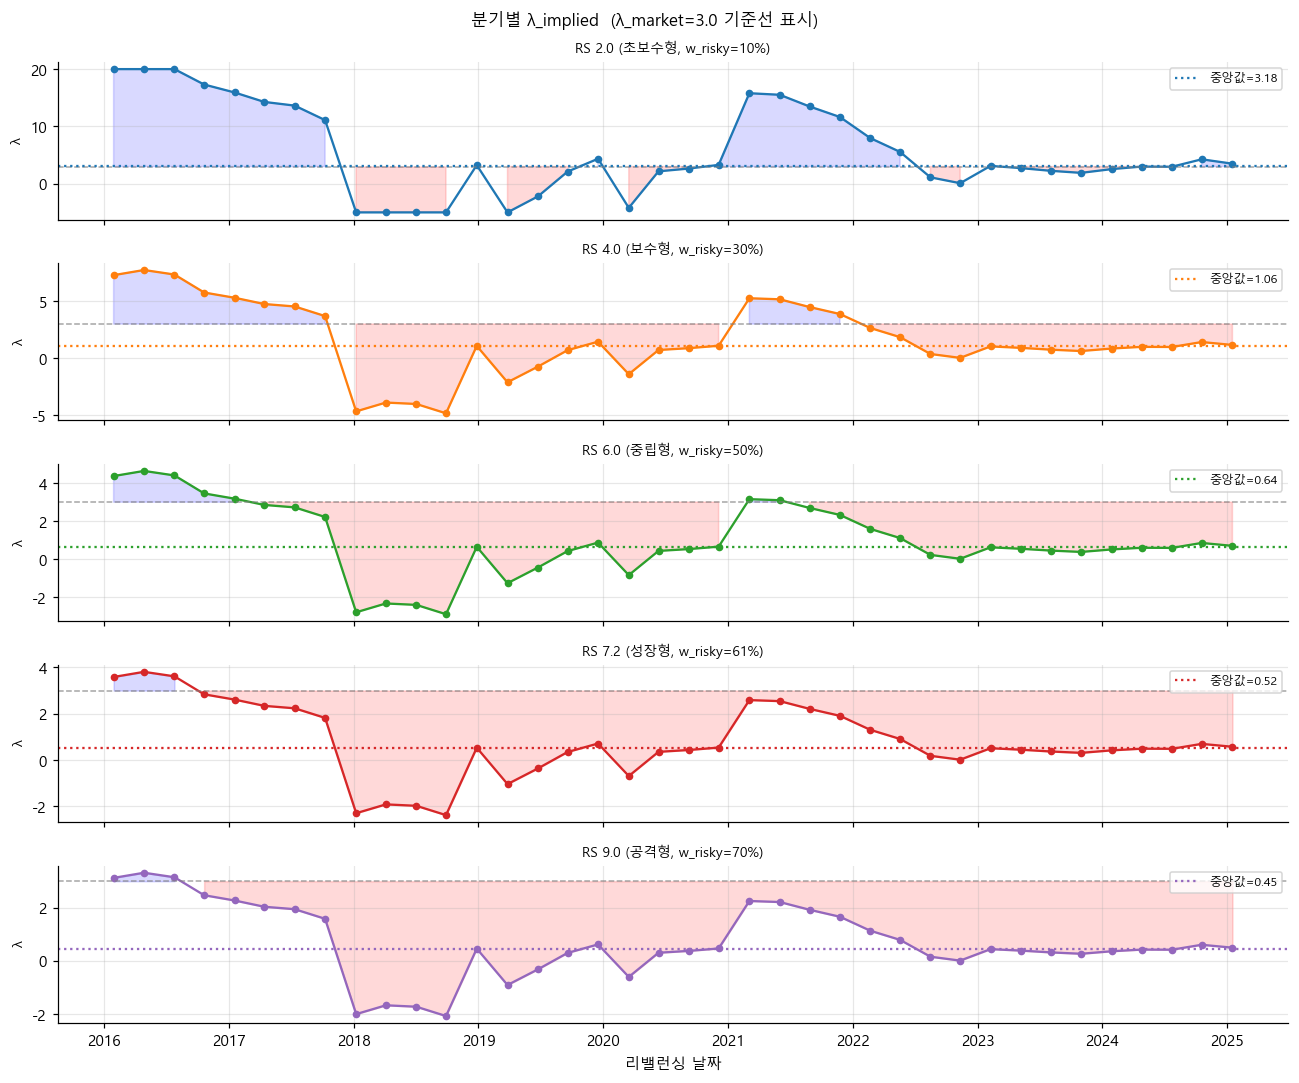

In [13]:
# ── λ_implied 시계열 (5개 Risk Score) ──
LAMBDA_MARKET = 3.0

fig, axes = plt.subplots(len(DEMO_SCORES), 1, figsize=(12, 10), sharex=True)
for ax, rs, color in zip(axes, DEMO_SCORES, SCORE_COLORS):
    sub = lam_df[lam_df['risk_score'] == rs].set_index('date').sort_index()
    lam = sub['lambda_implied'].clip(-5, 20)
    ax.plot(lam.index, lam.values, 'o-', color=color, lw=1.5, ms=4)
    ax.axhline(LAMBDA_MARKET, ls='--', color='gray', lw=1, alpha=0.7)
    ax.axhline(float(lam.median()), ls=':', color=color, lw=1.5,
               label=f'중앙값={lam.median():.2f}')
    ax.fill_between(lam.index, lam.values, LAMBDA_MARKET,
                    where=lam.values > LAMBDA_MARKET, alpha=0.15, color='blue')
    ax.fill_between(lam.index, lam.values, LAMBDA_MARKET,
                    where=lam.values < LAMBDA_MARKET, alpha=0.15, color='red')
    ax.set_ylabel('λ', fontsize=9)
    w_r = score_to_w_risky(rs) * 100
    ax.set_title(f"RS {rs} ({SCORE_LABELS[rs]}, w_risky={w_r:.0f}%)", fontsize=9)
    ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.3)

axes[-1].set_xlabel('리밸런싱 날짜')
fig.suptitle('분기별 λ_implied  (λ_market=3.0 기준선 표시)', fontsize=11)
plt.tight_layout()
plt.show()

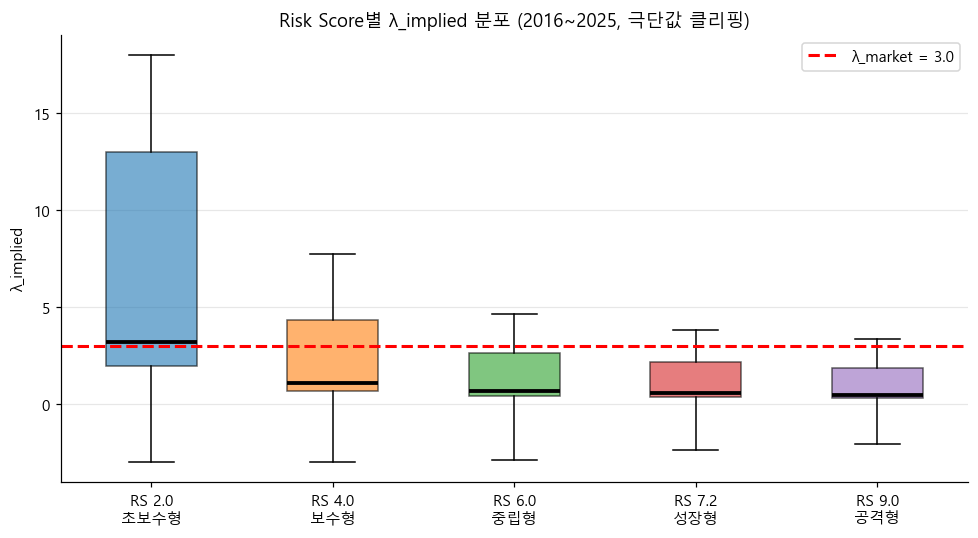

,위험군,w_risky,평균 λ,중앙값 λ,σ,λ>3.0 비율,해석
Risk Score,,,,,,,
2.0,초보수형,10%,4.991,3.182,9.606,52.6%,보수적
4.0,보수형,30%,1.664,1.061,3.202,31.6%,공격적
6.0,중립형,50%,0.998,0.636,1.921,18.4%,공격적
7.2,성장형,61%,0.818,0.522,1.575,7.9%,공격적
9.0,공격형,70%,0.713,0.455,1.372,7.9%,공격적


In [14]:
# ── λ_implied 분포 박스플롯 + 요약 테이블 ──
fig, ax = plt.subplots(figsize=(9, 5))
data_bp = [
    lam_df[lam_df['risk_score'] == rs]['lambda_implied'].clip(-3, 18).values
    for rs in DEMO_SCORES
]
xlabels = [f"RS {rs}\n{SCORE_LABELS[rs]}" for rs in DEMO_SCORES]
bp = ax.boxplot(data_bp, labels=xlabels, patch_artist=True,
                medianprops=dict(color='black', lw=2.5))
for patch, color in zip(bp['boxes'], SCORE_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.axhline(LAMBDA_MARKET, ls='--', color='red', lw=2,
           label=f'λ_market = {LAMBDA_MARKET}')
ax.set_ylabel('λ_implied')
ax.set_title('Risk Score별 λ_implied 분포 (2016~2025, 극단값 클리핑)')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 요약 테이블
rows = []
for rs in DEMO_SCORES:
    sub = lam_df[lam_df['risk_score'] == rs]['lambda_implied'].dropna()
    rows.append({
        'Risk Score': rs,
        '위험군': SCORE_LABELS[rs],
        'w_risky': f"{score_to_w_risky(rs)*100:.0f}%",
        '평균 λ': round(sub.mean(), 3),
        '중앙값 λ': round(sub.median(), 3),
        'σ': round(sub.std(), 3),
        'λ>3.0 비율': f"{(sub > LAMBDA_MARKET).mean()*100:.1f}%",
        '해석': '보수적' if sub.median() > LAMBDA_MARKET else '공격적',
    })
display(pd.DataFrame(rows).set_index('Risk Score'))

## 7. XAI 사용자 대면 시각화 (Step 8-A)

> **XAI 철학**: "추천"이 아닌 "참고 정보" — 투자자가 스스로 이해하고 결정하도록 지원합니다.

| 모듈 | 내용 |
|------|------|
| A0 기회비용 | 원리금보장 방치 vs 포트폴리오 활용 시 은퇴자산 차이 |
| A1 CAL 흐름 | Risk Score → w_risky → 최종 배분 결정 과정 |
| A2 수익기여 워터폴 | 자산군별 기대수익 기여도 분해 |
| A3 적립 경로 | 은퇴까지 예상 연금 자산 경로 (시나리오별) |
| A4 손실 감내도 | MDD를 적립금 금액으로 환산 |
| A5 λ_implied 게이지 | 내재 위험회피 수준 시각화 |
| A6 MVP vs Sortino | 두 전략의 리스크-리턴 비교 |

---
### ★ 투자자 입력값 — 이 셀만 수정 후 전체 실행

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  ★ 투자자 입력값  ← 이 셀만 수정하세요
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

RISK_SCORE      = 7.2    # 설문 합산 결과 (1~10, 별도 팀 산출)
CURRENT_BALANCE = 10000  # 현재 퇴직연금 적립금 (만원) — 예: 10000 = 1억
ANNUAL_SALARY   = 6000   # 연봉 (만원) — 예: 6000 = 6천만원
YEARS_TO_RETIRE = 25     # 은퇴까지 남은 연수

# ── 파생값 (수정 불필요) ──
W_RISKY   = score_to_w_risky(RISK_SCORE)
FINAL_W   = compute_cal_allocation(RISK_SCORE, cur_w.copy())
FINAL_W_M = compute_cal_allocation(RISK_SCORE, cur_mvp.copy())

TIER_BOUNDS = [(0,2,'초보수형'),(2,4,'보수형'),(4,6,'중립형'),(6,8,'성장형'),(8,10,'공격형')]
TIER = next((t for lo,hi,t in TIER_BOUNDS if lo <= RISK_SCORE < hi), '공격형')

PORT_RET  = ANN_RET_CON * W_RISKY
MVP_RET   = ANN_RET_MVP * W_RISKY
CAL_MDD   = MDD_CON * W_RISKY
CAL_MDD_M = MDD_MVP * W_RISKY

print(f"Risk Score : {RISK_SCORE}점 → {TIER}")
print(f"w_risky    : {W_RISKY*100:.0f}%  (무위험 {(1-W_RISKY)*100:.0f}%)")
print(f"적립금     : {CURRENT_BALANCE/1e4:.1f}억원")
print(f"연봉       : {ANNUAL_SALARY/1e4:.1f}억원  (월 {ANNUAL_SALARY/12/1e4:.2f}억)")
print(f"은퇴까지   : {YEARS_TO_RETIRE}년")
print(f"포트폴리오 기대 연수익 (CAL): {PORT_RET*100:.2f}%")

Risk Score : 7.2점 → 성장형
w_risky    : 61%  (무위험 39%)
적립금     : 1.0억원
연봉       : 0.6억원  (월 0.05억)
은퇴까지   : 25년
포트폴리오 기대 연수익 (CAL): 4.04%


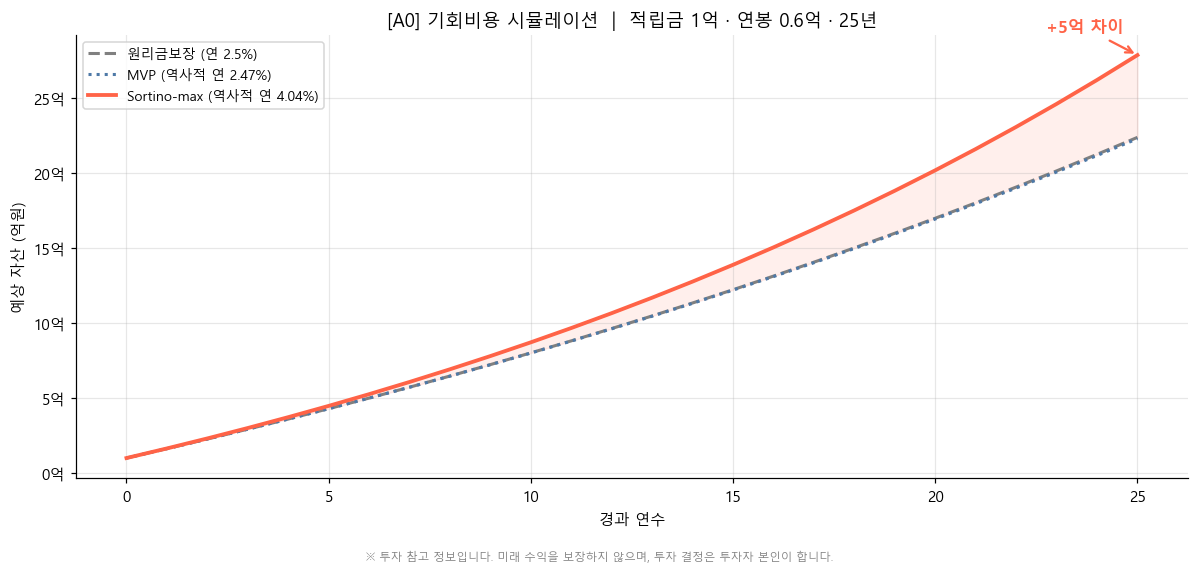

원리금보장  : 22.3억원
Sortino-max : 27.8억원
기회비용 차 : +5.5억원


In [16]:
# ── A0: 기회비용 시뮬레이션 ──
BENCH_RET = 0.025

def fv(balance, monthly_c, ann_r, yrs):
    if ann_r < 1e-6:
        return balance + monthly_c * 12 * yrs
    return balance * (1 + ann_r) ** yrs + monthly_c * ((1 + ann_r) ** yrs - 1) / (ann_r / 12)

monthly_c  = ANNUAL_SALARY / 12
fv_bench   = fv(CURRENT_BALANCE, monthly_c, BENCH_RET, YEARS_TO_RETIRE)
fv_port    = fv(CURRENT_BALANCE, monthly_c, PORT_RET,  YEARS_TO_RETIRE)
fv_mvp     = fv(CURRENT_BALANCE, monthly_c, MVP_RET,   YEARS_TO_RETIRE)
opp_cost   = fv_port - fv_bench

yr_range   = np.arange(0, YEARS_TO_RETIRE + 1)
path_bench = [fv(CURRENT_BALANCE, monthly_c, BENCH_RET, y) for y in yr_range]
path_port  = [fv(CURRENT_BALANCE, monthly_c, PORT_RET,  y) for y in yr_range]
path_mvp   = [fv(CURRENT_BALANCE, monthly_c, MVP_RET,   y) for y in yr_range]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yr_range, [v/1e4 for v in path_bench], '--', color='gray',    lw=2,
        label=f'원리금보장 (연 {BENCH_RET*100:.1f}%)')
ax.plot(yr_range, [v/1e4 for v in path_mvp],   ':',  color='#4e79a7', lw=2,
        label=f'MVP (역사적 연 {MVP_RET*100:.2f}%)')
ax.plot(yr_range, [v/1e4 for v in path_port],  '-',  color='tomato',  lw=2.5,
        label=f'Sortino-max (역사적 연 {PORT_RET*100:.2f}%)')
ax.fill_between(yr_range, [v/1e4 for v in path_bench], [v/1e4 for v in path_port],
                alpha=0.1, color='tomato')
ax.annotate(f'+{opp_cost/1e4:,.0f}억 차이',
            xy=(YEARS_TO_RETIRE, fv_port/1e4),
            xytext=(-60, 15), textcoords='offset points',
            fontsize=11, fontweight='bold', color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))
ax.set_xlabel('경과 연수')
ax.set_ylabel('예상 자산 (억원)')
ax.set_title(
    f'[A0] 기회비용 시뮬레이션  |  적립금 {CURRENT_BALANCE/1e4:.0f}억 · 연봉 {ANNUAL_SALARY/1e4:.1f}억 · {YEARS_TO_RETIRE}년'
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0f}억'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.text(0.5, -0.03, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout()
plt.show()

print(f"원리금보장  : {fv_bench/1e4:.1f}억원")
print(f"Sortino-max : {fv_port/1e4:.1f}억원")
print(f"기회비용 차 : {opp_cost/1e4:+.1f}억원")

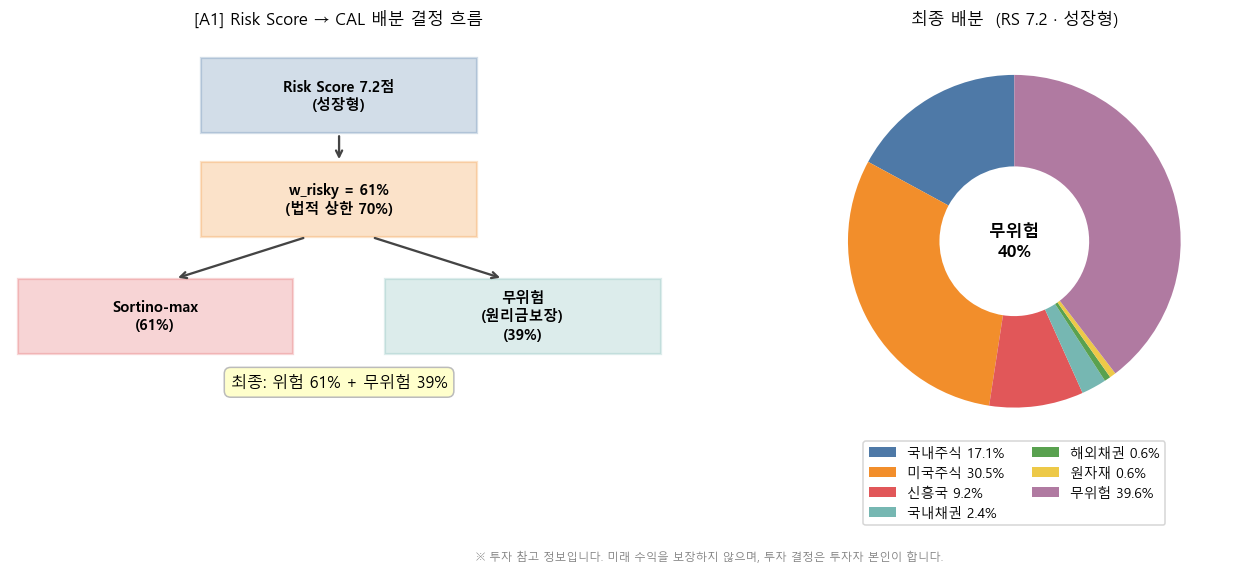

In [17]:
# ── A1: Risk Score → CAL 흐름도 + 최종 배분 도넛 ──
groups = {g: sum(float(FINAL_W.get(s, 0)) for s in slots)
          for g, slots in SLOTS_GROUPED.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                          gridspec_kw={'width_ratios': [1, 1.2]})

# 왼쪽: 흐름도
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
boxes = [
    (5, 8.5, f'Risk Score {RISK_SCORE:.1f}점\n({TIER})',          '#4e79a7'),
    (5, 6.0, f'w_risky = {W_RISKY*100:.0f}%\n(법적 상한 70%)',   '#f28e2b'),
    (2.2, 3.2, f'Sortino-max\n({W_RISKY*100:.0f}%)',              '#e15759'),
    (7.8, 3.2, f'무위험\n(원리금보장)\n({(1-W_RISKY)*100:.0f}%)', '#76b7b2'),
]
for x, y, txt, c in boxes:
    ax.add_patch(plt.Rectangle((x-2.1, y-0.9), 4.2, 1.8,
                               facecolor=c, alpha=0.25, edgecolor=c, lw=1.5))
    ax.text(x, y, txt, ha='center', va='center', fontsize=9.5, fontweight='bold')
for (x1,y1),(x2,y2) in [((5,7.6),(5,6.9)),((4.5,5.1),(2.5,4.1)),((5.5,5.1),(7.5,4.1))]:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#444'))
ax.text(5, 1.5, f'최종: 위험 {W_RISKY*100:.0f}% + 무위험 {(1-W_RISKY)*100:.0f}%',
        ha='center', fontsize=10.5,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffffcc', edgecolor='#bbb'))
ax.set_title('[A1] Risk Score → CAL 배분 결정 흐름', fontsize=11)

# 오른쪽: 도넛
ax2 = axes[1]
vals   = [v for v in groups.values() if v > 0.001]
glabs  = [k for k, v in groups.items() if v > 0.001]
colors = [GROUP_COLORS[list(SLOTS_GROUPED).index(g)] for g in glabs]
wedges, _ = ax2.pie(vals, colors=colors, startangle=90,
                    wedgeprops=dict(width=0.55))
ax2.text(0, 0, f"무위험\n{groups['무위험']*100:.0f}%",
         ha='center', va='center', fontsize=11, fontweight='bold')
ax2.legend(wedges, [f"{l} {v*100:.1f}%" for l,v in zip(glabs,vals)],
           loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5,-0.2))
ax2.set_title(f'최종 배분  (RS {RISK_SCORE:.1f} · {TIER})', fontsize=11)

fig.text(0.5, -0.03, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout()
plt.show()

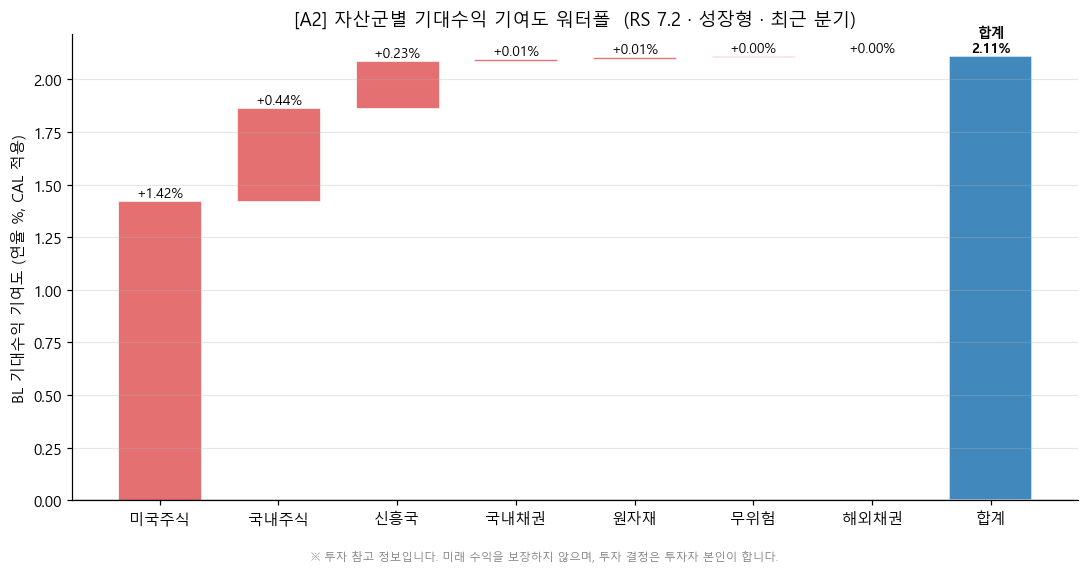

  총 기대수익 (BL, 연율): 2.110%
  미국주식  : +1.422%  (67.4%)
  국내주식  : +0.441%  (20.9%)
  신흥국   : +0.225%  (10.7%)
  국내채권  : +0.010%  (0.5%)
  원자재   : +0.009%  (0.4%)
  무위험   : +0.002%  (0.1%)
  해외채권  : +0.000%  (0.0%)


In [18]:
# ── A2: 자산군별 기대수익 기여도 워터폴 ──
# BL 내재수익률(Π) 기반 기여도 분해
last_pi = pi_h.iloc[-1]                         # 최근 분기 π (일별)
w_s     = w_con.iloc[-1]                        # 최근 분기 Sortino-max 비중

# w_risky 스케일 적용 후 최종 비중
w_final = w_s * W_RISKY
w_final['무위험(현금성)'] = float(w_s.get('무위험(현금성)', 0)) * W_RISKY + (1 - W_RISKY)

# 자산군별 기여도 집계 (연율 %)
contrib = {}
for g, slots in SLOTS_GROUPED.items():
    c = 0.0
    for s in slots:
        pi_val = float(last_pi.get(s, 0)) if pd.notna(last_pi.get(s, 0)) else 0.0
        c += float(w_final.get(s, 0)) * pi_val * 252 * 100
    contrib[g] = c

total_exp = sum(contrib.values())
sorted_contrib = sorted(contrib.items(), key=lambda x: x[1], reverse=True)

# 워터폴 차트
fig, ax = plt.subplots(figsize=(10, 5))
running = 0.0
x_pos   = 0
xticks  = []
xtick_labels = []

for g, val in sorted_contrib:
    color = '#e15759' if val >= 0 else '#4e79a7'
    ax.bar(x_pos, val, bottom=running, color=color, alpha=0.85,
           width=0.7, edgecolor='white', lw=0.5)
    ax.text(x_pos, running + val + (0.005 if val >= 0 else -0.015),
            f'{val:+.2f}%', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)
    running += val
    xticks.append(x_pos)
    xtick_labels.append(g)
    x_pos += 1

# 합계 바
ax.bar(x_pos, total_exp, color='#2c7bb6', alpha=0.9, width=0.7, edgecolor='white')
ax.text(x_pos, total_exp + 0.005, f'합계\n{total_exp:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
xticks.append(x_pos)
xtick_labels.append('합계')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)
ax.set_ylabel('BL 기대수익 기여도 (연율 %, CAL 적용)')
ax.set_title(
    f'[A2] 자산군별 기대수익 기여도 워터폴  (RS {RISK_SCORE:.1f} · {TIER} · 최근 분기)'
)
ax.grid(axis='y', alpha=0.3)
fig.text(0.5, -0.03, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout()
plt.show()

print(f"  총 기대수익 (BL, 연율): {total_exp:.3f}%")
for g, v in sorted_contrib:
    print(f"  {g:<6}: {v:+.3f}%  ({v/total_exp*100:.1f}%)")

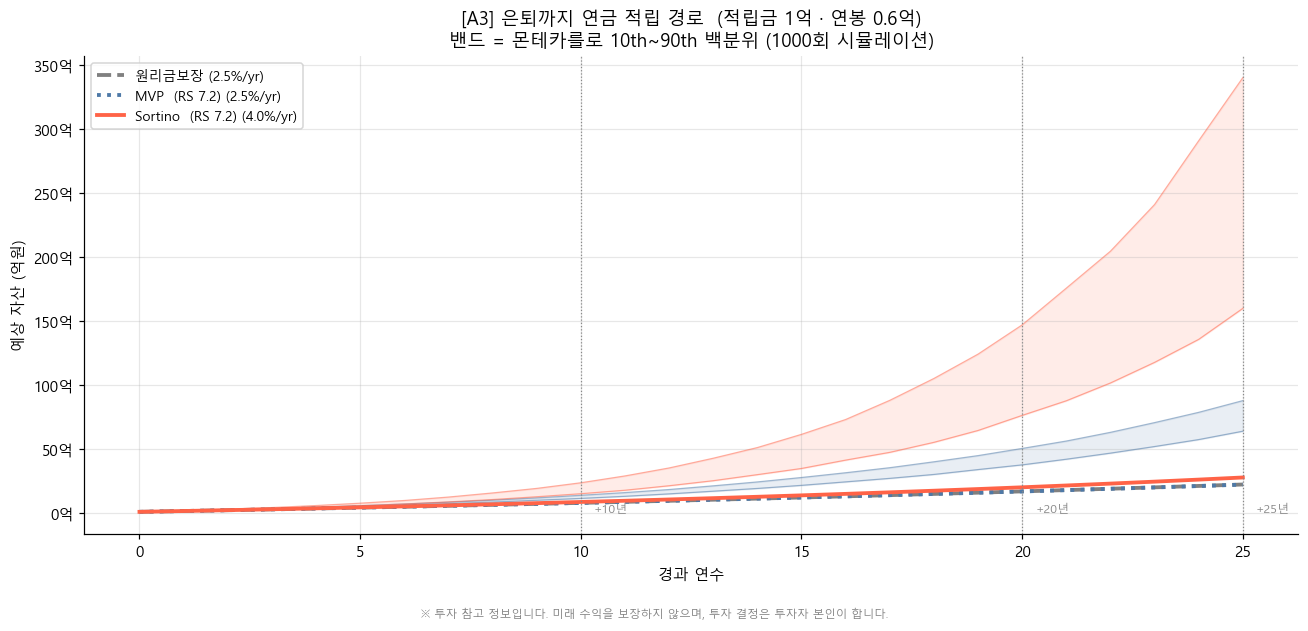

In [19]:
# ── A3: 은퇴까지 연금 적립 경로 (시나리오별 + 불확실성 밴드) ──
np.random.seed(2024)

# 전략별 연간 기대수익·변동성 (역사적 분기 OOS 기반)
scenarios = {
    '원리금보장': {
        'ret': BENCH_RET, 'vol': 0.001, 'color': 'gray', 'ls': '--'
    },
    f'MVP  (RS {RISK_SCORE:.1f})': {
        'ret': MVP_RET,
        'vol': float(perf_mvp['cum_ret_pct'].std() / 100 / np.sqrt(4)),
        'color': '#4e79a7', 'ls': ':'
    },
    f'Sortino  (RS {RISK_SCORE:.1f})': {
        'ret': PORT_RET,
        'vol': float(perf_con['cum_ret_pct'].std() / 100 / np.sqrt(4)),
        'color': 'tomato', 'ls': '-'
    },
}

N_SIM = 1000
years = np.arange(0, YEARS_TO_RETIRE + 1)

fig, ax = plt.subplots(figsize=(12, 5.5))

for label, cfg in scenarios.items():
    r, v, c, ls = cfg['ret'], cfg['vol'], cfg['color'], cfg['ls']

    # 결정론적 중앙선
    det_path = [fv(CURRENT_BALANCE, monthly_c, r, y) for y in years]
    ax.plot(years, [p/1e4 for p in det_path], lw=2.5, color=c, ls=ls,
            label=f'{label} ({r*100:.1f}%/yr)')

    # 몬테카를로 시뮬레이션 (불확실성 밴드)
    if v > 0.01:
        paths = np.zeros((N_SIM, len(years)))
        for sim in range(N_SIM):
            bal = float(CURRENT_BALANCE)
            paths[sim, 0] = bal
            for t in range(1, len(years)):
                annual_shocks = np.random.normal(r, v, 4)
                for q_r in annual_shocks:
                    bal = bal * (1 + q_r) + monthly_c * 3
                paths[sim, t] = bal
        p10 = np.percentile(paths, 10, axis=0) / 1e4
        p90 = np.percentile(paths, 90, axis=0) / 1e4
        ax.fill_between(years, p10, p90, alpha=0.12, color=c)
        ax.plot(years, p10, lw=0.8, color=c, alpha=0.5)
        ax.plot(years, p90, lw=0.8, color=c, alpha=0.5)

# 연도 마일스톤
for milestone in [10, 20, YEARS_TO_RETIRE]:
    if milestone <= YEARS_TO_RETIRE:
        ax.axvline(milestone, lw=0.8, color='#888', ls=':')
        ax.text(milestone + 0.3, ax.get_ylim()[0] * 1.05 if ax.get_ylim()[0] > 0 else 0.5,
                f'+{milestone}년', fontsize=8, color='#888')

ax.set_xlabel('경과 연수')
ax.set_ylabel('예상 자산 (억원)')
ax.set_title(
    f'[A3] 은퇴까지 연금 적립 경로  (적립금 {CURRENT_BALANCE/1e4:.0f}억 · 연봉 {ANNUAL_SALARY/1e4:.1f}억)\n'
    f'밴드 = 몬테카를로 10th~90th 백분위 ({N_SIM}회 시뮬레이션)'
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0f}억'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.text(0.5, -0.03, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout()
plt.show()

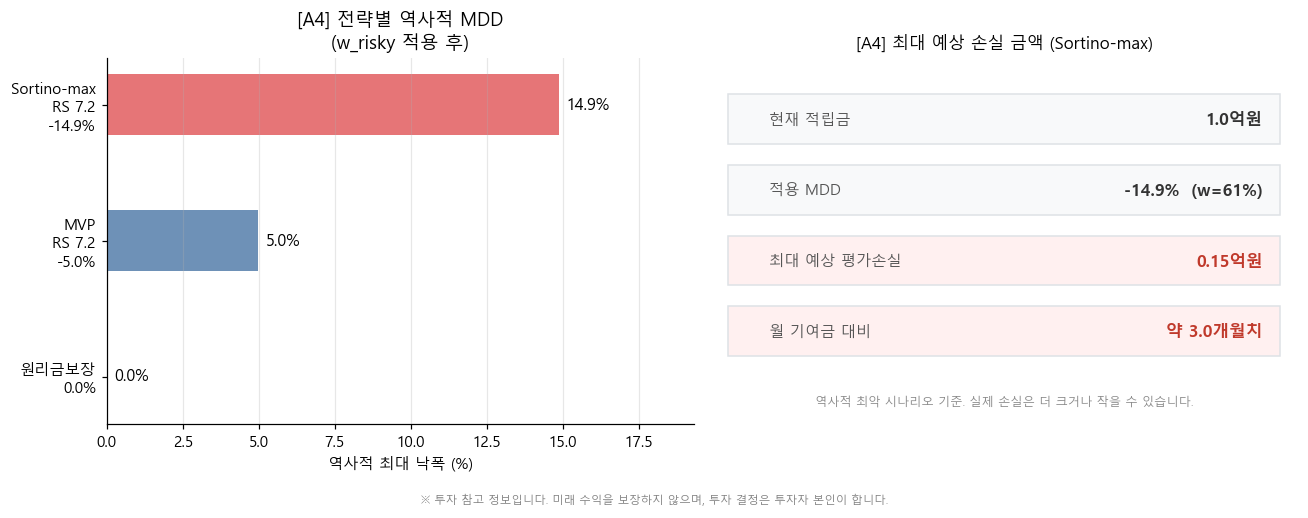

In [20]:
# ── A4: 손실 감내도 — MDD → 금액 환산 ──
loss_krw    = CURRENT_BALANCE * abs(CAL_MDD)
loss_months = loss_krw / (ANNUAL_SALARY / 12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# MDD 바 차트
ax = axes[0]
categories = ['원리금보장\n0.0%',
               f'MVP\nRS {RISK_SCORE:.1f}\n{CAL_MDD_M*100:.1f}%',
               f'Sortino-max\nRS {RISK_SCORE:.1f}\n{CAL_MDD*100:.1f}%']
mdd_vals = [0, abs(CAL_MDD_M)*100, abs(CAL_MDD)*100]
bars = ax.barh(categories, mdd_vals,
               color=['#76b7b2','#4e79a7','#e15759'], alpha=0.82, height=0.45)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=10.5)
ax.set_xlabel('역사적 최대 낙폭 (%)')
ax.set_title('[A4] 전략별 역사적 MDD\n(w_risky 적용 후)')
ax.set_xlim(0, max(mdd_vals) * 1.3)
ax.grid(axis='x', alpha=0.3)

# 금액 환산 카드
ax2 = axes[1]
ax2.axis('off'); ax2.set_xlim(0,10); ax2.set_ylim(0,7)
ax2.set_title('[A4] 최대 예상 손실 금액 (Sortino-max)', fontsize=11)
cards = [
    ('현재 적립금',       f'{CURRENT_BALANCE/1e4:.1f}억원',         '#f8f9fa'),
    ('적용 MDD',          f'{CAL_MDD*100:.1f}%  (w={W_RISKY*100:.0f}%)', '#f8f9fa'),
    ('최대 예상 평가손실', f'{loss_krw/1e4:.2f}억원',                '#fff0f0'),
    ('월 기여금 대비',     f'약 {loss_months:.1f}개월치',            '#fff0f0'),
]
for i, (lab, val, bg) in enumerate(cards):
    y = 5.8 - i * 1.35
    ax2.add_patch(plt.Rectangle((0.3, y-0.45), 9.4, 0.95,
                                facecolor=bg, edgecolor='#dee2e6', lw=1, zorder=2))
    ax2.text(1.0, y, lab, va='center', fontsize=10, color='#555', zorder=3)
    color = '#c0392b' if bg == '#fff0f0' else '#333'
    ax2.text(9.4, y, val, va='center', fontsize=11, ha='right',
             fontweight='bold', color=color, zorder=3)
ax2.text(5, 0.35, '역사적 최악 시나리오 기준. 실제 손실은 더 크거나 작을 수 있습니다.',
         ha='center', fontsize=8, color='#888', style='italic')

fig.text(0.5, -0.03, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout()
plt.show()

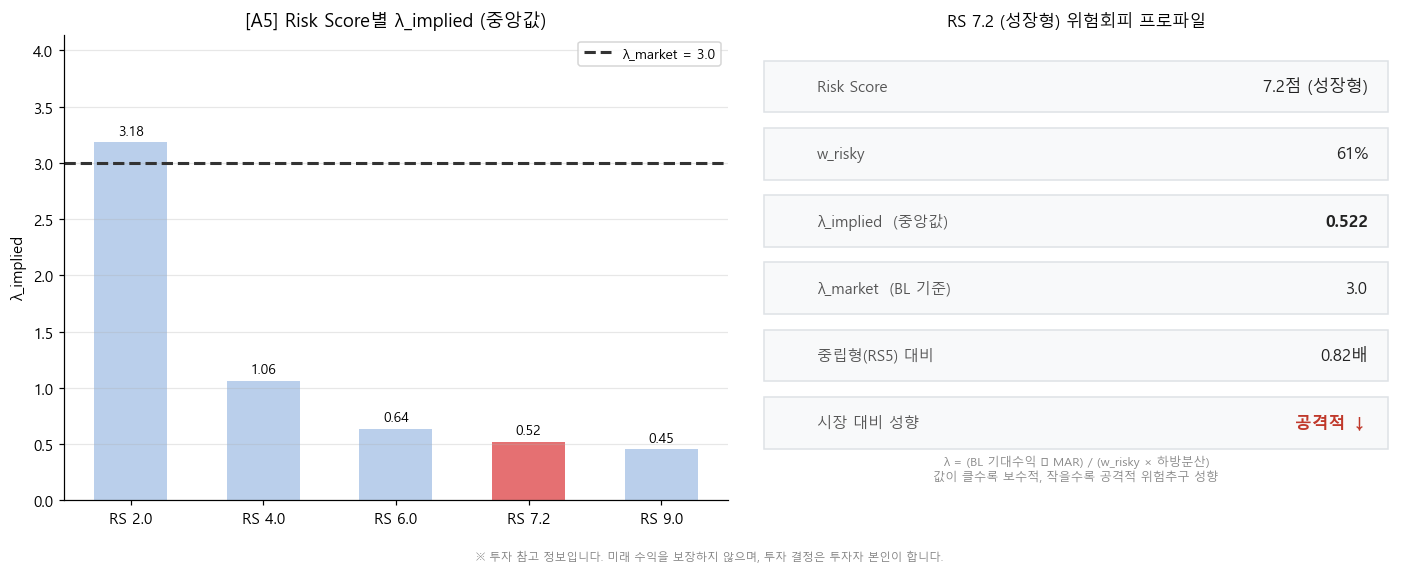

In [21]:
# ── A5: λ_implied 위험회피 게이지 ──
LAMBDA_MARKET = 3.0
demo_rs   = np.array(sorted(lam_df['risk_score'].unique()))
near_rs   = demo_rs[np.argmin(np.abs(demo_rs - RISK_SCORE))]
sub_lam   = lam_df[lam_df['risk_score'] == near_rs]['lambda_implied'].dropna()
lam_med   = float(sub_lam.median())

lam_by_rs = lam_df.groupby('risk_score')['lambda_implied'].median().sort_index()
neutral_lam = float(lam_by_rs.get(5.0, lam_by_rs.iloc[len(lam_by_rs)//2]))
rel_to_neutral = lam_med / neutral_lam if neutral_lam > 0 else float('nan')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RS별 λ 중앙값 바
ax = axes[0]
bar_c = ['#e15759' if abs(rs - near_rs) < 0.1 else '#aec7e8' for rs in lam_by_rs.index]
bars  = ax.bar([f'RS {rs:.1f}' for rs in lam_by_rs.index],
               lam_by_rs.values, color=bar_c, alpha=0.85, width=0.55)
ax.axhline(LAMBDA_MARKET, ls='--', color='#333', lw=2,
           label=f'λ_market = {LAMBDA_MARKET}')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_title('[A5] Risk Score별 λ_implied (중앙값)')
ax.set_ylabel('λ_implied')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(lam_by_rs.values) * 1.3)

# 프로파일 카드
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 9); ax2.axis('off')
ax2.set_title(f'RS {RISK_SCORE:.1f} ({TIER}) 위험회피 프로파일', fontsize=11)
direction = '보수적 ↑' if lam_med > LAMBDA_MARKET else '공격적 ↓'
dir_color = '#2471a3' if lam_med > LAMBDA_MARKET else '#c0392b'
items = [
    ('Risk Score',           f'{RISK_SCORE:.1f}점 ({TIER})'),
    ('w_risky',              f'{W_RISKY*100:.0f}%'),
    ('λ_implied  (중앙값)',  f'{lam_med:.3f}'),
    ('λ_market  (BL 기준)',  f'{LAMBDA_MARKET:.1f}'),
    ('중립형(RS5) 대비',     f'{rel_to_neutral:.2f}배'),
    ('시장 대비 성향',       direction),
]
for i, (lab, val) in enumerate(items):
    y = 8.0 - i * 1.3
    ax2.add_patch(plt.Rectangle((0.3, y-0.5), 9.4, 1.0,
                                facecolor='#f8f9fa', edgecolor='#dee2e6', lw=1))
    ax2.text(1.1, y, lab, va='center', fontsize=10, color='#555')
    c  = dir_color if lab == '시장 대비 성향' else '#222'
    fw = 'bold' if lab in ('시장 대비 성향','λ_implied  (중앙값)') else 'normal'
    ax2.text(9.4, y, val, va='center', fontsize=11, ha='right', color=c, fontweight=fw)
ax2.text(5, 0.4,
         'λ = (BL 기대수익 − MAR) / (w_risky × 하방분산)\n'
         '값이 클수록 보수적, 작을수록 공격적 위험추구 성향',
         ha='center', fontsize=8, color='#888', style='italic')

fig.text(0.5, -0.03, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout()
plt.show()

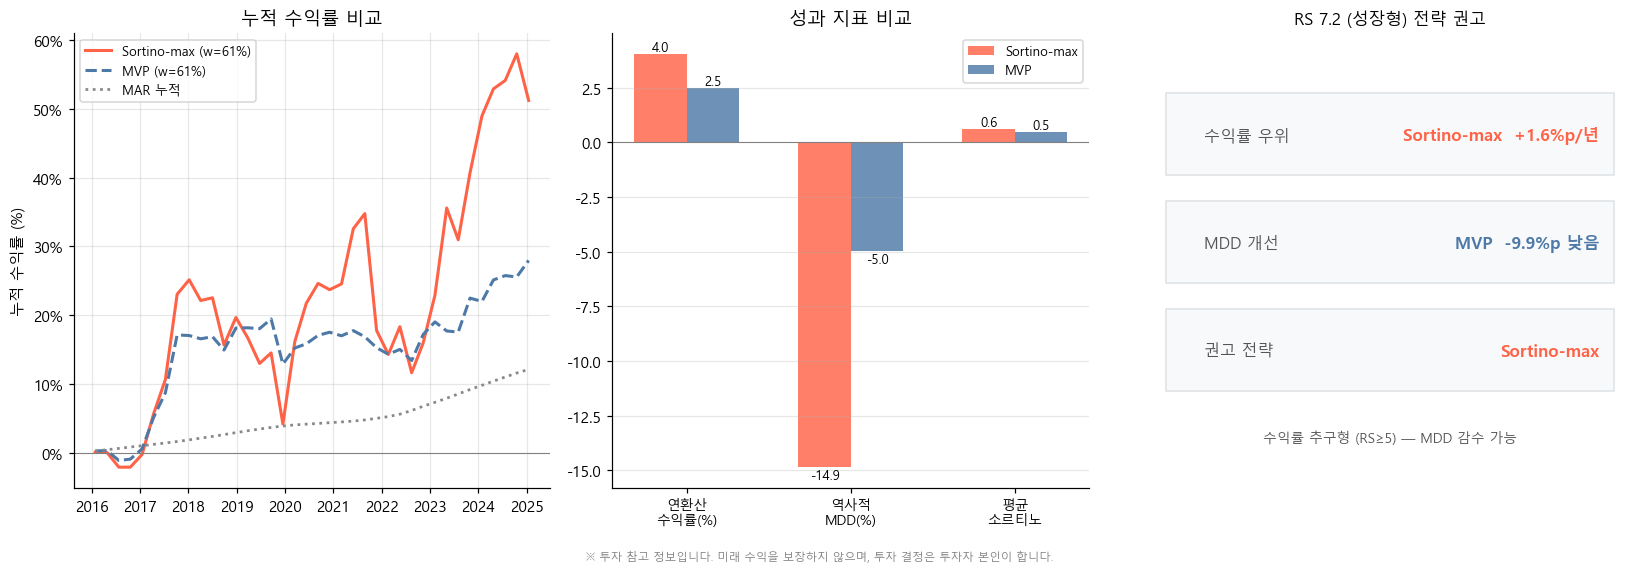


Sortino-max: 연환산 4.04%  MDD -14.85%
MVP        : 연환산 2.47%  MDD -4.97%
수익률 우위 : Sortino-max +1.57%p/년
권고 전략  : Sortino-max


In [22]:
# ── A6: MVP vs Sortino-max 비교 ──
cal_cum_con = (cum_con - 1) * W_RISKY * 100
cal_cum_mvp = (cum_mvp - 1) * W_RISKY * 100
ret_diff    = (ANN_RET_CON - ANN_RET_MVP) * W_RISKY * 100
mdd_diff    = (abs(CAL_MDD_M) - abs(CAL_MDD)) * 100
recommend   = 'Sortino-max' if RISK_SCORE >= 5 else 'MVP'
rec_color   = 'tomato' if recommend == 'Sortino-max' else '#4e79a7'

mar_q_rate = perf_con['mar_annual_pct'] / 100 / 4
cal_cum_mar = ((1 + mar_q_rate).cumprod() - 1) * W_RISKY * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 누적 수익률
ax = axes[0]
ax.plot(cal_cum_con.index, cal_cum_con.values, color='tomato',   lw=2, label=f'Sortino-max (w={W_RISKY*100:.0f}%)')
ax.plot(cal_cum_mvp.index, cal_cum_mvp.values, '--', color='#4e79a7', lw=2, label=f'MVP (w={W_RISKY*100:.0f}%)')
ax.plot(cal_cum_mar.index, cal_cum_mar.values, ':', color='#888', lw=1.8, label='MAR 누적')
ax.axhline(0, color='gray', lw=0.7)
ax.set_ylabel('누적 수익률 (%)')
ax.set_title('누적 수익률 비교')
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# 성과 지표 바 차트
ax2 = axes[1]
metrics  = ['연환산\n수익률(%)', '역사적\nMDD(%)', '평균\n소르티노']
con_vals = [ANN_RET_CON*W_RISKY*100, CAL_MDD*100, float(perf_con['sortino'].mean())]
mvp_vals = [ANN_RET_MVP*W_RISKY*100, CAL_MDD_M*100, float(perf_mvp['sortino'].mean())]
x = np.arange(len(metrics))
w = 0.32
b1 = ax2.bar(x-w/2, con_vals, w, label='Sortino-max', color='tomato',   alpha=0.82)
b2 = ax2.bar(x+w/2, mvp_vals, w, label='MVP',         color='#4e79a7', alpha=0.82)
ax2.set_xticks(x); ax2.set_xticklabels(metrics, fontsize=9)
ax2.set_title('성과 지표 비교')
ax2.axhline(0, color='gray', lw=0.7)
ax2.legend(fontsize=8.5); ax2.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    v = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, v+(0.15 if v>=0 else -0.55),
             f'{v:.1f}', ha='center', fontsize=8.5)

# 권고 카드
ax3 = axes[2]
ax3.axis('off'); ax3.set_xlim(0,10); ax3.set_ylim(0,8)
ax3.set_title(f'RS {RISK_SCORE:.1f} ({TIER}) 전략 권고', fontsize=11)
card_items = [
    ('수익률 우위', f'Sortino-max  +{ret_diff:.1f}%p/년', 'tomato'),
    ('MDD 개선',   f'MVP  {mdd_diff:.1f}%p 낮음',         '#4e79a7'),
    ('권고 전략',  recommend,                              rec_color),
]
for i, (lab, val, c) in enumerate(card_items):
    y = 6.2 - i * 1.9
    ax3.add_patch(plt.Rectangle((0.3, y-0.7), 9.4, 1.45,
                                facecolor='#f8f9fa', edgecolor='#dee2e6', lw=1))
    ax3.text(1.1, y, lab, va='center', fontsize=10.5, color='#555')
    ax3.text(9.4, y, val, va='center', fontsize=11, ha='right',
             fontweight='bold', color=c)
reason = ('수익률 추구형 (RS≥5) — MDD 감수 가능'
          if RISK_SCORE >= 5 else '안정추구형 (RS<5) — MDD 최소화 우선')
ax3.text(5, 0.8, reason, ha='center', fontsize=9, color='#555', style='italic')

fig.text(0.5, -0.03, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout()
plt.show()

print(f"\nSortino-max: 연환산 {ANN_RET_CON*W_RISKY*100:.2f}%  MDD {CAL_MDD*100:.2f}%")
print(f"MVP        : 연환산 {ANN_RET_MVP*W_RISKY*100:.2f}%  MDD {CAL_MDD_M*100:.2f}%")
print(f"수익률 우위 : Sortino-max +{ret_diff:.2f}%p/년")
print(f"권고 전략  : {recommend}")

## 8. 종합 요약

In [23]:
# ── 전체 파이프라인 핵심 지표 요약 ──
print("="*60)
print("  DC/IRP 퇴직연금 포트폴리오 최적화 — 핵심 지표 요약")
print("="*60)

print(f"\n▶ 모델 파라미터")
print(f"  λ (위험회피계수)   : 3.0  (퇴직연금 보수성)")
print(f"  추정 윈도우        : 5년 (1260거래일)")
print(f"  리밸런싱 주기      : 분기 (63거래일)")
print(f"  MAR               : ECOS 정기예금 6개월미만 (시변)")
print(f"  지역 제약          : US≤50%, KR≤50%, EM≤15%")
print(f"  슬롯 비중 범위     : 1%~40% (개별 슬롯)")

print(f"\n▶ 백테스트 결과 (2016~2025, {len(w_con)}분기)")
print(f"  {'전략':<18} {'연환산':>8} {'누적':>8} {'MDD':>8} {'소르티노>0':>10}")
print("  " + "-"*50)
for label, perf, cum_s in [
    ('Sortino-max', perf_con, cum_con),
    ('MVP',         perf_mvp, cum_mvp),
]:
    ann = float(cum_s.iloc[-1] ** (4/len(cum_s)) - 1)
    mdd = _mdd(cum_s)
    pct = float((perf['sortino'] > 0).mean())
    print(f"  {label:<18} {ann*100:>7.2f}% {(cum_s.iloc[-1]-1)*100:>7.1f}% {mdd*100:>7.2f}% {pct*100:>9.1f}%")

print(f"\n▶ Risk Score → w_risky 앵커")
for rs, lab in [(1,'초보수형'),(3,'보수형'),(5,'중립형'),(7,'성장형'),(9,'공격형')]:
    print(f"  RS {rs} ({lab:<5}) : w_risky = {score_to_w_risky(rs)*100:.0f}%")

print(f"\n▶ λ_implied 요약 (BL 기대수익률 기반)")
print(f"  λ_market = 3.0  (Step 5 확정 BL 파라미터)")
for rs in DEMO_SCORES:
    sub = lam_df[lam_df['risk_score'] == rs]['lambda_implied'].dropna()
    pct_above = (sub > LAMBDA_MARKET).mean() * 100
    direction = '보수적' if sub.median() > LAMBDA_MARKET else '공격적'
    print(f"  RS {rs:<4} ({SCORE_LABELS[rs]:<5}) 중앙값={sub.median():.3f}  "
          f"λ>3 비율={pct_above:.1f}%  ({direction})")

print(f"\n▶ 현재 시점 투자자 설정 (RS {RISK_SCORE:.1f} · {TIER})")
print(f"  w_risky           : {W_RISKY*100:.0f}%")
print(f"  기대 연수익 (CAL) : {PORT_RET*100:.2f}%")
print(f"  CAL 적용 MDD      : {CAL_MDD*100:.2f}%")
print(f"  최대 예상 손실    : {CURRENT_BALANCE*abs(CAL_MDD)/1e4:.2f}억원")
print(f"  권고 전략         : {recommend}")
print(f"\n" + "="*60)
print(DISCLAIMER)

  DC/IRP 퇴직연금 포트폴리오 최적화 — 핵심 지표 요약

▶ 모델 파라미터
  λ (위험회피계수)   : 3.0  (퇴직연금 보수성)
  추정 윈도우        : 5년 (1260거래일)
  리밸런싱 주기      : 분기 (63거래일)
  MAR               : ECOS 정기예금 6개월미만 (시변)
  지역 제약          : US≤50%, KR≤50%, EM≤15%
  슬롯 비중 범위     : 1%~40% (개별 슬롯)

▶ 백테스트 결과 (2016~2025, 38분기)
  전략                      연환산       누적      MDD     소르티노>0
  --------------------------------------------------
  Sortino-max           6.63%    84.0%  -24.35%      60.5%
  MVP                   4.05%    45.8%   -8.15%      50.0%

▶ Risk Score → w_risky 앵커
  RS 1 (초보수형 ) : w_risky = 0%
  RS 3 (보수형  ) : w_risky = 20%
  RS 5 (중립형  ) : w_risky = 40%
  RS 7 (성장형  ) : w_risky = 60%
  RS 9 (공격형  ) : w_risky = 70%

▶ λ_implied 요약 (BL 기대수익률 기반)
  λ_market = 3.0  (Step 5 확정 BL 파라미터)
  RS 2.0  (초보수형 ) 중앙값=3.182  λ>3 비율=52.6%  (보수적)
  RS 4.0  (보수형  ) 중앙값=1.061  λ>3 비율=31.6%  (공격적)
  RS 6.0  (중립형  ) 중앙값=0.636  λ>3 비율=18.4%  (공격적)
  RS 7.2  (성장형  ) 중앙값=0.522  λ>3 비율=7.9%  (공격적)
  RS 9.0  (공격형  ) 중앙값=0.455  λ>3 비율=7.9%  